# CELL 1 - Imports & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, f1_score, log_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from scipy.stats import ks_2samp
import joblib
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix,
    f1_score, log_loss, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression as LR
from scipy.stats import ks_2samp
import scipy.stats as stats
import pickle

# NOTE: SMOTE removed — using class_weight='balanced' instead
# SMOTE distorts base rates making PD over-estimated after training

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Load cleaned data (stratified sample from notebook 01)
df = pd.read_csv('../data/cleaned_loan_data.csv')

print(" Libraries imported and data loaded")
print(f"   Rows     : {df.shape[0]:,}")
print(f"   Columns  : {df.shape[1]}")
print(f"   Defaults : {df['default'].sum():,} ({df['default'].mean()*100:.1f}%)")
print(f"\n   Columns available: {list(df.columns)}")

 Libraries imported and data loaded
   Rows     : 122,216
   Columns  : 31
   Defaults : 26,702 (21.8%)

   Columns available: ['id', 'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'out_prncp', 'total_rec_prncp', 'recoveries', 'collection_recovery_fee', 'issue_year', 'default', 'fico_score', 'credit_history_years']


# CELL 2 - Weight of Evidence (WoE) Encoding

In [2]:
# CHANGES FROM PREVIOUS VERSION:
# 1. purpose explicitly excluded before WoE (IV=0.018 < 0.02)
# 2. debt_burden engineered feature added
# 3. log_annual_inc replaces annual_inc
# 4. Explicit column count printed for verification
# ============================================================

def calc_woe_iv(df, col, target):
    total_events     = df[target].sum()
    total_non_events = len(df) - total_events
    woe_dict = {}
    iv = 0
    for val in df[col].unique():
        mask    = df[col] == val
        events  = df.loc[mask, target].sum()
        non_ev  = mask.sum() - events
        dist_ev  = max(events, 0.5) / total_events
        dist_nev = max(non_ev, 0.5) / total_non_events
        woe = np.log(dist_ev / dist_nev)
        iv += (dist_ev - dist_nev) * woe
        woe_dict[val] = woe
    return woe_dict, iv


df_model = df.copy()
woe_maps   = {}
iv_scores  = {}
iv_summary = []

# Only encode features that PASS the IV threshold
# purpose (IV=0.018) is excluded — it adds noise not signal
cat_cols_encode = ['grade', 'sub_grade', 'home_ownership', 'verification_status']
cat_cols_skip   = ['purpose']   # IV < 0.02 — skip encoding, drop below

# Also calculate IV for skipped cols so the summary table is complete
for col in cat_cols_skip:
    _, iv = calc_woe_iv(df_model, col, 'default')
    iv_scores[col] = iv
    iv_summary.append({"Feature": col, "IV": round(iv, 4), "Action": "Drop (IV < 0.02 threshold)"})

for col in cat_cols_encode:
    woe_dict, iv = calc_woe_iv(df_model, col, 'default')
    df_model[col] = df_model[col].map(woe_dict)
    woe_maps[col]  = woe_dict
    iv_scores[col] = iv
    iv_summary.append({"Feature": col, "IV": round(iv, 4), "Action": "Keep"})

# Print IV summary
iv_df = pd.DataFrame(iv_summary).sort_values('IV', ascending=False)
print("=== IV SCORES (Industry threshold: <0.02 Useless, 0.02-0.1 Weak, >0.3 Strong) ===")
print(iv_df.to_string(index=False))
print()

# --- Feature Engineering ---
# debt_burden: monthly payment as % of monthly income
# More predictive than DTI alone — captures actual cash flow stress
df_model['debt_burden'] = (
    df_model['installment'] / (df_model['annual_inc'] / 12)
).clip(0, 5)

# log_annual_inc: fixes right-skew in income distribution
# Log transform is standard preprocessing for income in credit models
df_model['log_annual_inc'] = np.log1p(df_model['annual_inc'])

print("=== ENGINEERED FEATURES ===")
print(f"   debt_burden    — mean: {df_model['debt_burden'].mean():.4f}, "
      f"median: {df_model['debt_burden'].median():.4f}, "
      f"max(clipped): {df_model['debt_burden'].max():.4f}")
print(f"   log_annual_inc — mean: {df_model['log_annual_inc'].mean():.4f}, "
      f"std: {df_model['log_annual_inc'].std():.4f}")
print()

# --- Final Feature Matrix ---
drop_cols = [
    'id', 'loan_status', 'default',
    'recoveries', 'collection_recovery_fee', 'total_rec_prncp',
    'issue_d', 'issue_year', 'out_prncp',
    'annual_inc',   # replaced by log_annual_inc
    'purpose'       # dropped: IV < 0.02
]

X = df_model.drop(columns=drop_cols)
y = df_model['default']

# Save WoE maps (only encoded cols — purpose excluded)
with open('../src/woe_maps.pkl', 'wb') as f:
    pickle.dump(woe_maps, f)

print("=== FINAL FEATURE SET ===")
print(f"   Features retained : {X.shape[1]}")
print(f"   Samples           : {X.shape[0]:,}")
print(f"\n   Feature list:")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2d}. {col}")

print(f"\n Cell 2 complete — X shape: {X.shape} | y shape: {y.shape}")
print(f" WoE maps saved (4 features encoded)")

=== IV SCORES (Industry threshold: <0.02 Useless, 0.02-0.1 Weak, >0.3 Strong) ===
            Feature     IV                     Action
          sub_grade 0.4745                       Keep
              grade 0.4401                       Keep
verification_status 0.0511                       Keep
     home_ownership 0.0325                       Keep
            purpose 0.0180 Drop (IV < 0.02 threshold)

=== ENGINEERED FEATURES ===
   debt_burden    — mean: 0.0799, median: 0.0722, max(clipped): 5.0000
   log_annual_inc — mean: 11.0841, std: 0.5372

=== FINAL FEATURE SET ===
   Features retained : 22
   Samples           : 122,216

   Feature list:
    1. loan_amnt
    2. funded_amnt
    3. term
    4. int_rate
    5. installment
    6. grade
    7. sub_grade
    8. emp_length
    9. home_ownership
   10. verification_status
   11. dti
   12. delinq_2yrs
   13. inq_last_6mths
   14. open_acc
   15. pub_rec
   16. revol_bal
   17. revol_util
   18. total_acc
   19. fico_score
   20. credi

# Cell 3 - Train/Test Split:

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train/Test Split")
print(f"   Train : {X_train.shape[0]:,} rows | Defaults: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"   Test  : {X_test.shape[0]:,} rows  | Defaults: {y_test.sum():,} ({y_test.mean()*100:.1f}%)")

# 5-fold stratified cross-validation on training set
# Using a quick LR with default C to get a baseline CV AUC
# Hyperparameter tuning happens in Cell 4
print("\nRunning 5-fold stratified cross-validation...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)

cv_scores = cross_val_score(
    lr_cv,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"\n5-Fold CV Results (Logistic Regression, C=1.0 default)")
print(f"   Fold AUCs : {[round(float(s), 4) for s in cv_scores]}")
print(f"   Mean AUC  : {cv_scores.mean():.4f}")
print(f"   Std Dev   : {cv_scores.std():.4f}  (lower = more stable)")
print(f"   95% CI    : [{cv_scores.mean() - 2*cv_scores.std():.4f}, "
      f"{cv_scores.mean() + 2*cv_scores.std():.4f}]")

if cv_scores.std() < 0.005:
    stability = "Very stable — low variance across folds"
elif cv_scores.std() < 0.01:
    stability = "Stable — acceptable variance"
else:
    stability = "Some variance — check for data inconsistencies"

print(f"   Stability : {stability}")
print(f"\nNote: CV AUC here uses default C=1.0.")
print(f"Cell 4 will tune C and report final AUC on held-out test set.")

Train/Test Split
   Train : 97,772 rows | Defaults: 21,361 (21.8%)
   Test  : 24,444 rows  | Defaults: 5,341 (21.8%)

Running 5-fold stratified cross-validation...

5-Fold CV Results (Logistic Regression, C=1.0 default)
   Fold AUCs : [0.71, 0.7116, 0.7121, 0.7108, 0.7093]
   Mean AUC  : 0.7108
   Std Dev   : 0.0010  (lower = more stable)
   95% CI    : [0.7087, 0.7128]
   Stability : Very stable — low variance across folds

Note: CV AUC here uses default C=1.0.
Cell 4 will tune C and report final AUC on held-out test set.


# Cell 4 - Logistic Regression: Hyperparameter Tuning + Full Metrics:

In [4]:
# --- 1. Tune regularisation strength C via grid search ---
# C controls inverse regularisation: smaller C = stronger penalty
# Searching log-scale is standard practice for LR tuning
param_grid = {'C': [0.01, 0.1, 1, 10]}

lr_base = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)

grid_search = GridSearchCV(
    lr_base,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)

best_C   = grid_search.best_params_['C']
best_auc = grid_search.best_score_

print("Hyperparameter Tuning — Logistic Regression")
print(f"   C values tested : {param_grid['C']}")
print(f"   Best C          : {best_C}")
print(f"   Best CV AUC     : {best_auc:.4f}")

print("\n   All C results:")
for mean, std, params in zip(
    grid_search.cv_results_['mean_test_score'],
    grid_search.cv_results_['std_test_score'],
    grid_search.cv_results_['params']
):
    print(f"   C={params['C']:5} -> AUC {mean:.4f} (+/- {std:.4f})")

# --- 2. Train final model with best C ---
lr_model = LogisticRegression(
    C=best_C,
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)
lr_model.fit(X_train_scaled, y_train)

# --- 3. Predictions at default threshold (0.5) ---
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_pred_05    = lr_model.predict(X_test_scaled)

# --- 4. Core metrics ---
lr_auc   = roc_auc_score(y_test, lr_pred_proba)
lr_aucpr = average_precision_score(y_test, lr_pred_proba)
lr_gini  = 2 * lr_auc - 1
lr_loss  = log_loss(y_test, lr_pred_proba)

ks_stat, _ = ks_2samp(
    lr_pred_proba[y_test == 0],
    lr_pred_proba[y_test == 1]
)

# --- 5. Optimal threshold (maximise F1) ---
# Default 0.5 threshold is arbitrary for imbalanced data
# Banks care more about capturing defaults (recall) than precision
precisions, recalls, thresholds = precision_recall_curve(y_test, lr_pred_proba)
f1_scores  = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)
optimal_idx       = f1_scores.argmax()
optimal_threshold = thresholds[optimal_idx]
best_f1           = f1_scores[optimal_idx]

lr_pred_optimal = (lr_pred_proba >= optimal_threshold).astype(int)

print(f"\nLogistic Regression — Final Results (C={best_C})")
print(f"   AUC-ROC            : {lr_auc:.4f}   (industry benchmark: >0.65 acceptable, >0.70 good)")
print(f"   AUC-PR             : {lr_aucpr:.4f}   (precision-recall; more informative for imbalanced data)")
print(f"   KS Statistic       : {ks_stat:.4f}   (benchmark: >0.30 good, >0.40 strong)")
print(f"   Gini Coefficient   : {lr_gini:.4f}   (benchmark: >0.30 acceptable, >0.40 good)")
print(f"   Log Loss           : {lr_loss:.4f}")
print(f"\n   Threshold Analysis:")
print(f"   Default threshold  : 0.5000  ->  F1 = {f1_score(y_test, lr_pred_05):.4f}")
print(f"   Optimal threshold  : {optimal_threshold:.4f}  ->  F1 = {best_f1:.4f}")
print(f"\n   Classification Report (optimal threshold = {optimal_threshold:.4f}):")
print(classification_report(y_test, lr_pred_optimal, target_names=['Non-Default', 'Default']))

Hyperparameter Tuning — Logistic Regression
   C values tested : [0.01, 0.1, 1, 10]
   Best C          : 0.01
   Best CV AUC     : 0.7108

   All C results:
   C= 0.01 -> AUC 0.7108 (+/- 0.0010)
   C=  0.1 -> AUC 0.7108 (+/- 0.0010)
   C=    1 -> AUC 0.7108 (+/- 0.0010)
   C=   10 -> AUC 0.7108 (+/- 0.0011)

Logistic Regression — Final Results (C=0.01)
   AUC-ROC            : 0.7045   (industry benchmark: >0.65 acceptable, >0.70 good)
   AUC-PR             : 0.3994   (precision-recall; more informative for imbalanced data)
   KS Statistic       : 0.2952   (benchmark: >0.30 good, >0.40 strong)
   Gini Coefficient   : 0.4089   (benchmark: >0.30 acceptable, >0.40 good)
   Log Loss           : 0.6264

   Threshold Analysis:
   Default threshold  : 0.5000  ->  F1 = 0.4440
   Optimal threshold  : 0.5143  ->  F1 = 0.4455

   Classification Report (optimal threshold = 0.5143):
              precision    recall  f1-score   support

 Non-Default       0.87      0.66      0.75     19103
     Defa

# Cell 5 - Random Forest + Gradient Boosting Challenger Models

In [5]:

# --- Random Forest ---
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
rf_pred       = (rf_pred_proba >= 0.5).astype(int)

rf_auc   = roc_auc_score(y_test, rf_pred_proba)
rf_aucpr = average_precision_score(y_test, rf_pred_proba)
rf_gini  = 2 * rf_auc - 1
rf_loss  = log_loss(y_test, rf_pred_proba)
ks_stat_rf, _ = ks_2samp(
    rf_pred_proba[y_test == 0],
    rf_pred_proba[y_test == 1]
)

print(f"   AUC-ROC : {rf_auc:.4f} | AUC-PR : {rf_aucpr:.4f} | "
      f"KS : {ks_stat_rf:.4f} | Gini : {rf_gini:.4f}")

# --- Gradient Boosting ---
# GradientBoostingClassifier does not support class_weight
# Use sample_weight instead — equivalent effect
print("\nTraining Gradient Boosting...")

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

gb_pred_proba = gb_model.predict_proba(X_test_scaled)[:, 1]
gb_pred       = (gb_pred_proba >= 0.5).astype(int)

gb_auc   = roc_auc_score(y_test, gb_pred_proba)
gb_aucpr = average_precision_score(y_test, gb_pred_proba)
gb_gini  = 2 * gb_auc - 1
gb_loss  = log_loss(y_test, gb_pred_proba)
ks_stat_gb, _ = ks_2samp(
    gb_pred_proba[y_test == 0],
    gb_pred_proba[y_test == 1]
)

print(f"   AUC-ROC : {gb_auc:.4f} | AUC-PR : {gb_aucpr:.4f} | "
      f"KS : {ks_stat_gb:.4f} | Gini : {gb_gini:.4f}")

# --- Three-way summary ---
print("\n" + "="*65)
print(f"{'Model':<25} {'AUC-ROC':>8} {'AUC-PR':>8} {'KS':>8} {'Gini':>8}")
print("="*65)
print(f"{'Logistic Regression':<25} {lr_auc:>8.4f} {lr_aucpr:>8.4f} "
      f"{ks_stat:>8.4f} {lr_gini:>8.4f}")
print(f"{'Random Forest':<25} {rf_auc:>8.4f} {rf_aucpr:>8.4f} "
      f"{ks_stat_rf:>8.4f} {rf_gini:>8.4f}")
print(f"{'Gradient Boosting':<25} {gb_auc:>8.4f} {gb_aucpr:>8.4f} "
      f"{ks_stat_gb:>8.4f} {gb_gini:>8.4f}")
print("="*65)

# Determine best model by AUC
scores = {'Logistic Regression': lr_auc, 'Random Forest': rf_auc, 'Gradient Boosting': gb_auc}
best_model_name = max(scores, key=scores.get)
print(f"\nBest model by AUC-ROC : {best_model_name} ({scores[best_model_name]:.4f})")
print("Note: Final model selection in Cell 6 after visual comparison.")

Training Random Forest...
   AUC-ROC : 0.7026 | AUC-PR : 0.3931 | KS : 0.2935 | Gini : 0.4052

Training Gradient Boosting...
   AUC-ROC : 0.7115 | AUC-PR : 0.4079 | KS : 0.3046 | Gini : 0.4230

Model                      AUC-ROC   AUC-PR       KS     Gini
Logistic Regression         0.7045   0.3994   0.2952   0.4089
Random Forest               0.7026   0.3931   0.2935   0.4052
Gradient Boosting           0.7115   0.4079   0.3046   0.4230

Best model by AUC-ROC : Gradient Boosting (0.7115)
Note: Final model selection in Cell 6 after visual comparison.


# Cell 6 - Visual Model Comparison (ROC, PR, Distributions)

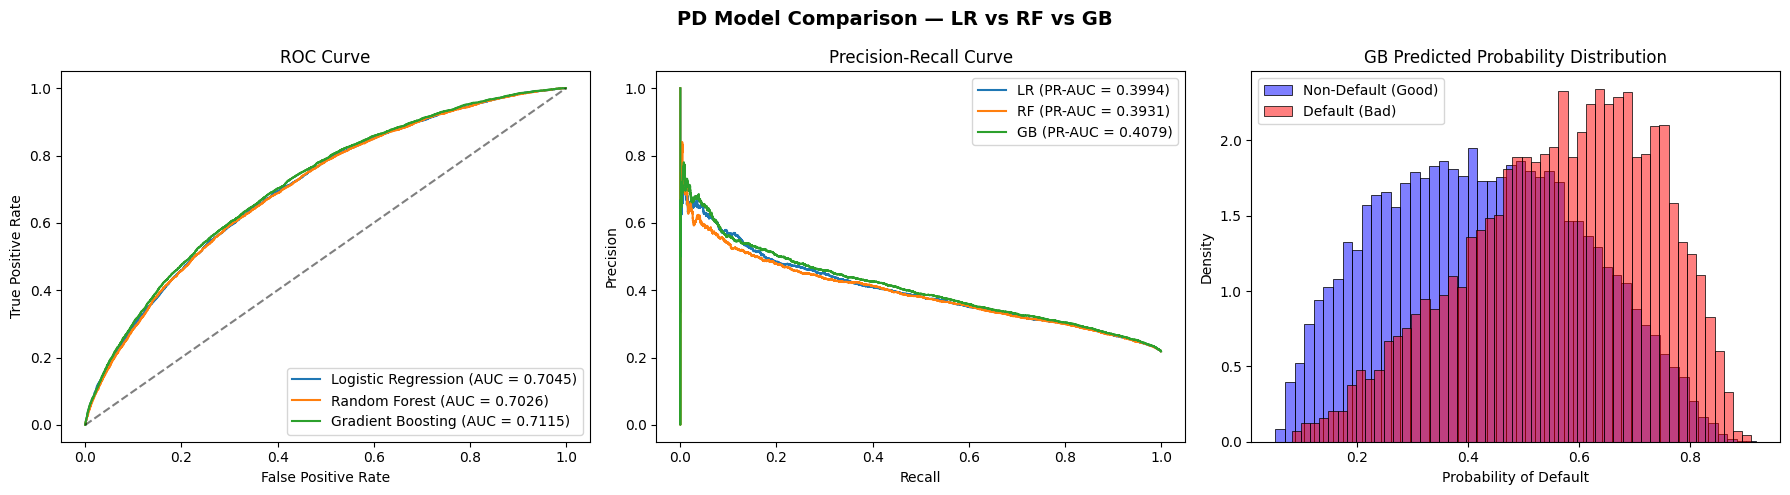

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PD Model Comparison — LR vs RF vs GB', fontsize=14, fontweight='bold')

# --- 1. ROC Curves ---
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_pred_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_proba)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_pred_proba)

axes[0].plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.4f})')
axes[0].plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.4f})')
axes[0].plot(gb_fpr, gb_tpr, label=f'Gradient Boosting (AUC = {gb_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# --- 2. Precision-Recall Curves ---
lr_prec, lr_rec, _ = precision_recall_curve(y_test, lr_pred_proba)
rf_prec, rf_rec, _ = precision_recall_curve(y_test, rf_pred_proba)
gb_prec, gb_rec, _ = precision_recall_curve(y_test, gb_pred_proba)

axes[1].plot(lr_rec, lr_prec, label=f'LR (PR-AUC = {lr_aucpr:.4f})')
axes[1].plot(rf_rec, rf_prec, label=f'RF (PR-AUC = {rf_aucpr:.4f})')
axes[1].plot(gb_rec, gb_prec, label=f'GB (PR-AUC = {gb_aucpr:.4f})')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right')

# --- 3. Predicted Probability Distributions (Gradient Boosting) ---
sns.histplot(gb_pred_proba[y_test == 0], bins=50, color='blue', alpha=0.5, label='Non-Default (Good)', ax=axes[2], stat='density')
sns.histplot(gb_pred_proba[y_test == 1], bins=50, color='red', alpha=0.5, label='Default (Bad)', ax=axes[2], stat='density')
axes[2].set_title('GB Predicted Probability Distribution')
axes[2].set_xlabel('Probability of Default')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.show()

# Cell 7 - SHAP Explainability:

Calculating SHAP values for Gradient Boosting...
Using a random sample of 2000 test rows for computation speed.


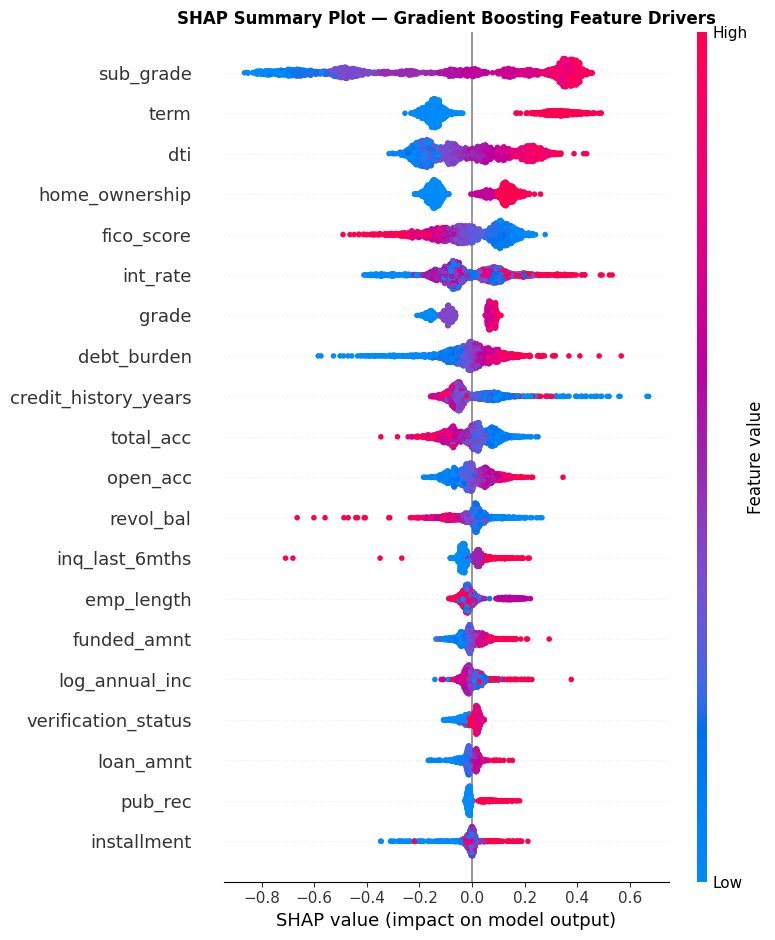

In [7]:
import shap
print("Calculating SHAP values for Gradient Boosting...")
print("Using a random sample of 2000 test rows for computation speed.")

# 1. Initialize the TreeExplainer (optimized for Gradient Boosting)
explainer = shap.TreeExplainer(gb_model)

# 2. Subsample the test set for performance
np.random.seed(42)
sample_indices = np.random.choice(X_test_scaled.shape[0], size=2000, replace=False)
X_test_sample = X_test_scaled[sample_indices]

# 3. Calculate SHAP values
shap_values = explainer.shap_values(X_test_sample)

# 4. Generate the Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot — Gradient Boosting Feature Drivers", fontsize=12, fontweight='bold')

# Try to use original feature names if X_train was a DataFrame prior to scaling
try:
    feature_names = X_train.columns.tolist()
    shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, show=False)
except AttributeError:
    # Fallback just in case X_train was converted to a pure numpy array without columns
    shap.summary_plot(shap_values, X_test_sample, show=False)

plt.tight_layout()
plt.show()

# Cell 8 - Probability Calibration and Saving the Model

Probability Calibration — Gradient Boosting (Platt Scaling)
   Actual default rate          : 0.2185 (21.85%)
   Before calibration (mean PD) : 0.4565 (45.65%)
   After  calibration (mean PD) : 0.2192  (21.92%)
   Calibration gap              : 23.80% -> 0.07%
   AUC preserved                : 0.7101


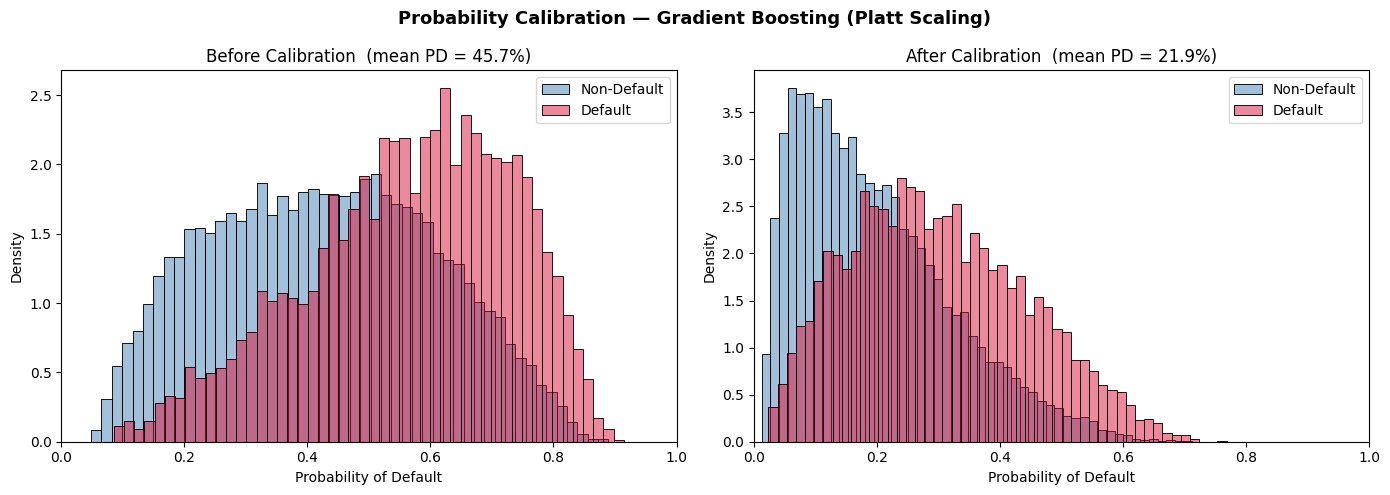


Models saved:
   src/pd_model.pkl      — Gradient Boosting (retrained on 80% of train)
   src/platt_model.pkl   — Platt Scaling calibrator
   src/scaler.pkl        — StandardScaler

Predictions saved:
   data/pd_predictions.csv
   data/pd_predictions_with_year.csv
   Total rows : 24,444
   Predicted defaults : 953 (3.9%)


In [9]:
from sklearn.linear_model import LogisticRegression as PlattLR
from sklearn.model_selection import train_test_split
# --- 1. Carve a calibration set from training data ---
# Re-split train into train2 (80%) and cal (20%)
# gb_model was trained on X_train_scaled/y_train — we use a
# held-out portion of that same pool for calibration
X_tr2, X_cal, y_tr2, y_cal = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Retrain GB on the reduced train2 set
sample_weights_tr2 = compute_sample_weight(class_weight='balanced', y=y_tr2)

gb_model_cal = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
gb_model_cal.fit(X_tr2, y_tr2, sample_weight=sample_weights_tr2)

# --- 2. Platt Scaling on calibration set ---
# Map raw decision scores to calibrated probabilities
raw_cal_scores = gb_model_cal.decision_function(X_cal).reshape(-1, 1)

platt = PlattLR(random_state=42, max_iter=500)
platt.fit(raw_cal_scores, y_cal)

# --- 3. Evaluate on true held-out test set ---
raw_test_scores  = gb_model_cal.decision_function(X_test_scaled).reshape(-1, 1)
calibrated_proba = platt.predict_proba(raw_test_scores)[:, 1]
raw_proba        = gb_model_cal.predict_proba(X_test_scaled)[:, 1]

# --- 4. Diagnostics ---
actual_rate    = y_test.mean()
mean_before    = raw_proba.mean()
mean_after     = calibrated_proba.mean()
gap_before     = abs(mean_before - actual_rate) * 100
gap_after      = abs(mean_after  - actual_rate) * 100

print("Probability Calibration — Gradient Boosting (Platt Scaling)")
print(f"   Actual default rate          : {actual_rate:.4f} ({actual_rate*100:.2f}%)")
print(f"   Before calibration (mean PD) : {mean_before:.4f} ({mean_before*100:.2f}%)")
print(f"   After  calibration (mean PD) : {mean_after:.4f}  ({mean_after*100:.2f}%)")
print(f"   Calibration gap              : {gap_before:.2f}% -> {gap_after:.2f}%")
print(f"   AUC preserved                : {roc_auc_score(y_test, calibrated_proba):.4f}")

# --- 5. Visualise before vs after ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Probability Calibration — Gradient Boosting (Platt Scaling)',
             fontsize=13, fontweight='bold')

sns.histplot(raw_proba[y_test == 0], bins=50, color='steelblue',
             alpha=0.5, label='Non-Default', ax=axes[0], stat='density')
sns.histplot(raw_proba[y_test == 1], bins=50, color='crimson',
             alpha=0.5, label='Default', ax=axes[0], stat='density')
axes[0].set_title(f'Before Calibration  (mean PD = {mean_before*100:.1f}%)')
axes[0].set_xlabel('Probability of Default')
axes[0].set_xlim(0, 1)
axes[0].legend()

sns.histplot(calibrated_proba[y_test == 0], bins=50, color='steelblue',
             alpha=0.5, label='Non-Default', ax=axes[1], stat='density')
sns.histplot(calibrated_proba[y_test == 1], bins=50, color='crimson',
             alpha=0.5, label='Default', ax=axes[1], stat='density')
axes[1].set_title(f'After Calibration  (mean PD = {mean_after*100:.1f}%)')
axes[1].set_xlabel('Probability of Default')
axes[1].set_xlim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/pd_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 6. Save models and predictions ---
joblib.dump(gb_model_cal, '../src/pd_model.pkl')
joblib.dump(platt,        '../src/platt_model.pkl')
joblib.dump(scaler,       '../src/scaler.pkl')

# Save predictions — full test set with calibrated PD
pd_results = pd.DataFrame({
    'id'             : df.iloc[y_test.index]['id'].values,
    'issue_year'     : df.iloc[y_test.index]['issue_year'].values,
    'actual_default' : y_test.values,
    'pd_raw'         : raw_proba,
    'pd_probability' : calibrated_proba,
    'pd_predicted'   : (calibrated_proba >= 0.5).astype(int)
})
pd_results.to_csv('../data/pd_predictions.csv', index=False)
pd_results.to_csv('../data/pd_predictions_with_year.csv', index=False)

print(f"\nModels saved:")
print(f"   src/pd_model.pkl      — Gradient Boosting (retrained on 80% of train)")
print(f"   src/platt_model.pkl   — Platt Scaling calibrator")
print(f"   src/scaler.pkl        — StandardScaler")
print(f"\nPredictions saved:")
print(f"   data/pd_predictions.csv")
print(f"   data/pd_predictions_with_year.csv")
print(f"   Total rows : {len(pd_results):,}")
print(f"   Predicted defaults : {pd_results['pd_predicted'].sum():,} "
      f"({pd_results['pd_predicted'].mean()*100:.1f}%)")